In [2]:
from pathlib import Path
import os

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.contexts import GenomeContext, PlasmidContext
from gena_expression.genome import Genome, GenomeRegion
from gena_expression.models import SequenceModel, VariantInterpreter
from gena_expression.scorers import (
    ExpressionDeltaScorer,
    TrackWindowScorer,
    TrackFeatureScorer,
    TrackAllFeaturesScorer
)
from gena_expression.results import ScoringResult
from gena_expression.sequences import AnnotatedSequence, Feature, SequencePair
from gena_expression.variants import Variant

from gena_expression.plasmids import PlasmidRecord, infer_table18_primer_tails, PlasmidCollection
from gena_expression.CONST import table18_primers, locations, enhancer_to_mpra_plasmid, promoter_to_mpra_plasmid
from typing import Any, Literal, Mapping, Sequence

In [3]:
API_ROOT = Path("/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api")
DATA_DIR = API_ROOT / "data"

MPRA_TABLE = DATA_DIR / "mpra_cagi5" / "Kircher_GRCh38_ALL.tsv"
DESCRIPTION_DIR = DATA_DIR / "rna_seq_generated_descriptions"
#DESCRIPTION_DIR = DATA_DIR / "atacseq_generated_descriptions"

PLASMID_DIR = DATA_DIR / "plasmids"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa")
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
)

DEVICE = "cuda:3"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__()

ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")
GENA_LM_ROOT = ROOT / "GENA_LM"
EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS_PATH = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS_PATH}::ExpressionCounts"

#MODEL_CHECKPOINT = ROOT / "models" / "expression_model_latest" / "pytorch_model.bin"
MODEL_CHECKPOINT = ROOT / "models" / "expression_model" / "pytorch_model.bin"
#MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml"
MODEL_CONFIG = EXPRESSION_TASK_DIR / 'configs' / "final.yaml"
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

In [4]:
ENHANCERS_CELL_TYPES = {
    "HEK293T","HEL92.1.7",
    "HaCaT", "HeLa",
    "HepG2", "K562",
    "LNCaP", "MIN6",
    "NIH-3T3", "Neuro-2a",
    "SF7996", "SK-MEL-28",
}
PROMOTERS_CELL_TYPE = {
    "HEK293T", "HEL92.1.7",
    "HaCaT", "HeLa",
    "HepG2", "K562",
    "LNCaP", "MIN6",
    "NIH-3T3", "Neuro-2a",
    "SF7996", "SK-MEL-28",
}
ALL_CELL_TYPES = list(ENHANCERS_CELL_TYPES | PROMOTERS_CELL_TYPE)

ELEMENT_TO_PLASMID = enhancer_to_mpra_plasmid | promoter_to_mpra_plasmid

In [5]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/genome.py:423: RuntimeWarning: Plain GTF/GFF annotations are not supported directly for fast interval queries; using existing compressed annotation /workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz. debug={'plain_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf', 'compressed_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expr

In [6]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=ALL_CELL_TYPES
)

conditions = {
    name: Condition(name=name, description=lookup[name])
    for name in lookup.keys()
}

In [7]:
dataset = pl.read_csv(
    MPRA_TABLE,
    separator="\t",
    infer_schema_length=10_000,
)

dataset = dataset.filter(pl.col.Tags>10).with_columns(
    (
        pl.lit("chr")
        + pl.col("Chromosome").cast(pl.String)
        + pl.lit(":")
        + pl.col("Position").cast(pl.String)
        + pl.lit(":")
        + pl.col("Ref").cast(pl.String)
        + pl.lit(">")
        + pl.col("Alt").cast(pl.String)
    ).alias("variant")
)

In [8]:
dataset = dataset.filter(pl.col.Element == 'HBG1').head(2)

In [9]:
dataset

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""HBG1""","""HEL92.1.7""","""11""",5249804,"""G""","""-""",526,20437,62593,0.09,0.02787,"""chr11:5249804:G>-"""
"""HBG1""","""HEL92.1.7""","""11""",5249804,"""G""","""A""",267,12253,39772,0.19,0.00108,"""chr11:5249804:G>A"""


In [10]:
import tqdm

In [11]:
sequence_pairs : Sequence[SequencePair] = []
conditions = []
for element, cell_type, variant in tqdm.tqdm(dataset.select('Element', 'Cell_Type', 'variant').iter_rows(), total=dataset.__len__()):
    variant = Variant.from_str(variant, genome = genome, coordinate_system='0-based')
    variant.validate(genome=genome)
    sequence_pair = variant.to_sequence_pair(genome=genome,
                                                primer_pairs=table18_primers, 
                                                #primer_pair_name=element.split('-')[0].split('.')[0], 
                                                primer_locations=locations,
                                                primer_flank_bp=1000,
                                                primer_location_padding_bp=100,
                                                name=element)
    #condition = Condition(name=cell_type, description=lookup[cell_type])
    sequence_pairs.append(sequence_pair)
    #conditions.append(condition)

100%|██████████| 2/2 [00:00<00:00, 546.03it/s]


In [12]:
tails = infer_table18_primer_tails(GENOME_FASTA, flank=200, min_match=15, table18_primers=table18_primers, locations=locations)
plasmid_collection_context_aug = PlasmidCollection(
    element_to_plasmid=ELEMENT_TO_PLASMID,
    data_storage=PLASMID_DIR,
    circular=True,
    primer_tails=tails,
    reporter_feature_name="luc2",
    allow_repeats=False,
    context_size=20_000,
).element_name_based_context

plasmid_collection_context_no_aug = PlasmidCollection(
    element_to_plasmid=ELEMENT_TO_PLASMID,
    data_storage=PLASMID_DIR,
    circular=True,
    primer_tails=tails,
    reporter_feature_name="luc2",
    allow_repeats=False,
    context_size=None,
).element_name_based_context

safe_harbor_context = GenomeRegion(
    genome_path=GENOME_FASTA,
).genomic_context(
    region="AAVS1",
    target_length=20_000,
)

In [13]:
from concurrent.futures import ProcessPoolExecutor
import tqdm

def _add_context_to_sequence(seq):
    element_name = seq.name.split("_")[0]

    plasmid_context = plasmid_collection_context_no_aug(
        seq,
        element_name
    )
    return safe_harbor_context(plasmid_context)
    #return plasmid_context


def _add_context_to_pair(pair):
    return pair.map(_add_context_to_sequence)

with ProcessPoolExecutor(
    max_workers=10
) as executor:
    sequence_pairs = list(
        tqdm.tqdm(
            executor.map(
                _add_context_to_pair,
                sequence_pairs,
                chunksize=100,
            ),
            total=len(sequence_pairs),
            desc="Adding genomic contexts",
        )
    )

Adding genomic contexts: 100%|██████████| 2/2 [00:00<00:00, 91.07it/s]


In [14]:
def _rev_comp(pair: SequencePair):
    return pair.map(lambda seq: seq.reverse_complement())

with ProcessPoolExecutor(
    max_workers=10
) as executor:
    reverse_complement_pairs = list(
        tqdm.tqdm(
            executor.map(
                _rev_comp,
                sequence_pairs,
                chunksize=100,
            ),
            total=len(sequence_pairs),
            desc="Making reverse complement pairs",
        )
    )

Making reverse complement pairs: 100%|██████████| 2/2 [00:00<00:00, 2017.95it/s]


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': '19:55115008'}, xlabel='Sequence coordinate'>)

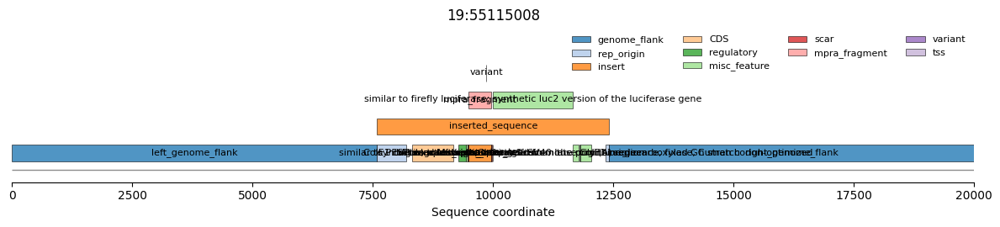

In [15]:
sequence_pairs[0].ref.plot_annotations()

In [16]:
sequence_pairs[0].ref.feature_frame()

,name,start,end,type,strand,source,metadata
0,left_genome_flank,0,7582,genome_flank,NaN,genome,"{'chromosome': '19', 'start': 55107426, 'end':..."
1,source,7582,9435,source,+,genbank,"{'location': '1..4372', 'qualifiers': {'organi..."
2,ColE1 origin,7582,8193,rep_origin,+,genbank,"{'location': '2448..3130', 'qualifiers': {'not..."
3,beta-lactamase,8316,9177,CDS,-,genbank,"{'location': 'complement(3254..4114)', 'qualif..."
4,synthetic; transcriptional pause site,9281,9435,regulatory,+,genbank,"{'location': '4219..4372', 'qualifiers': {'reg..."
5,source,9435,12417,source,+,genbank,"{'location': '1..4372', 'qualifiers': {'organi..."
6,Altered Multiple Cloning Site,9435,9474,misc_feature,+,genbank,"{'location': '1..72', 'qualifiers': {'note': '..."
7,similar to firefly luciferase; synthetic luc2 ...,9999,11649,misc_feature,+,genbank,"{'location': '102..1751', 'qualifiers': {'note..."
8,similar to PEST degradation sequence from mous...,11652,11775,misc_feature,+,genbank,"{'location': '1755..1877', 'qualifiers': {'not..."
9,sequence was changed from the original sequenc...,11792,11808,misc_feature,+,genbank,"{'location': '1895..1910', 'qualifiers': {'not..."


In [17]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=100,
    device=DEVICE,
)

interpreter = VariantInterpreter(model)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:262: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementat

Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [18]:
track_scorer = TrackWindowScorer(
    track="atac",
    center="reporter_tss",
    width_bp=501,
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='track_window'
)
track_feature_scorer = TrackFeatureScorer(
    features=['mpra_insert'],
    track="atac",
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='mpra_insert',
)
all_features_scorer = TrackAllFeaturesScorer(track="atac", aggregate="sum")

In [19]:
import logging

logging.basicConfig(level=logging.INFO)

In [38]:
lookup = DescriptionLookup(
    json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata',
    keys=['ENCFF024KOW', 'ENCFF015XFX']
)

conditions = {
    name: Condition(name=name, description=lookup[name])
    for name in lookup.keys()
}

In [79]:
sequence = genome.sequence(chrom='chr11',
                           start=5248079,
                           end=5249859+512*20,
                           strand='-')
pred = model.predict_sequence(
    sequence=sequence,
    condition=lookup['ENCFF024KOW'],
    center=512*20+100
)

INFO:gena_expression.models:Predict Sequence: 1 row(s), 1 forward batch(es), grouping=no_grouping, preprocessing=process/0, prefetch=0
INFO:gena_expression.models:Predict Sequence complete


In [80]:
pred.expression

5.65625

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

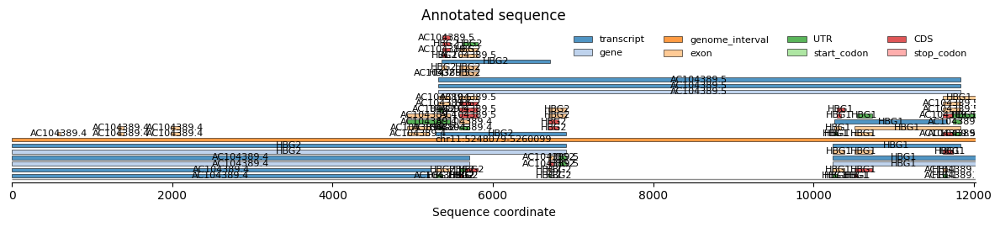

In [45]:
sequence.plot_annotations()

In [37]:
results = interpreter.score_sequence_pairs(
    pairs=sequence_pairs,
    #conditions=conditions,
    conditions=[lookup['ENCFF024KOW'] for _ in sequence_pairs],
    #scorer=all_features_scorer,
    scorer = ExpressionDeltaScorer(),
    grouping="no_grouping",
    max_pairs_per_forward=200,
    preprocessing_workers=10,
    prefetch_batches=2,
    show_progress=True,
    pair_execution='joint',
    center='tss'
)

INFO:gena_expression.models:Starting process preprocessing with 10 worker(s)
INFO:gena_expression.models:Predicting allele pairs: 4 row(s), 1 forward batch(es), grouping=pair, preprocessing=process/10, prefetch=2
Exception in initializer:
Traceback (most recent call last):
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/concurrent/futures/process.py", line 240, in _process_worker
    initializer(*initargs)
  File "/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py", line 69, in _process_worker_init
    from transformers import AutoTokenizer
  File "<frozen importlib._bootstrap>", line 1229, in _handle_fromlist
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/transformers/utils/import_utils.py", line 2292, in __getattr__
    module = self._get_module(self._class_to_module[name])
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/site

KeyboardInterrupt: 

(<Figure size 640x480 with 4 Axes>,
 <Axes: title={'center': 'delta_track'}, xlabel='Sequence coordinate', ylabel='delta_track'>)

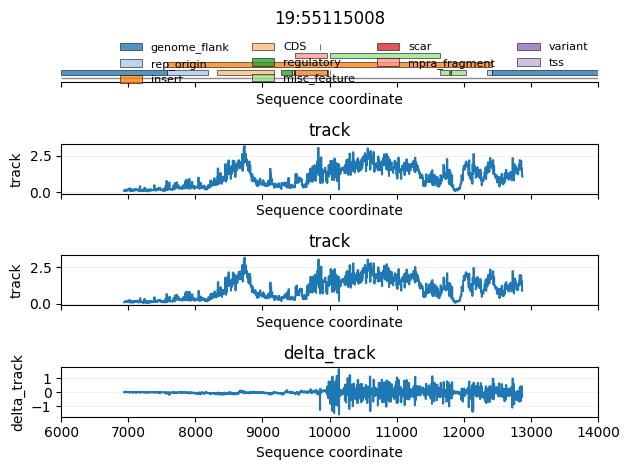

In [39]:
fig, axs = plt.subplots(nrows=4, sharex=True)
results[0].prediction.ref.sequence.plot_annotations(ax=axs[0], label_features=False, start=6000, end=14_000)
results[0].prediction.ref.track().plot(color_by_sign=False, ax=axs[1])
results[0].prediction.alt.track().plot(color_by_sign=False, ax=axs[2])
results[0].prediction.delta_track().plot(color_by_sign=False, ax=axs[3])

In [62]:
promoter_hbg = results[0].prediction.ref.sequence.select('mpra_insert').sequence

AnnotatedSequence(sequence='CCTCTATGATGGGAGAAGGAAACTAGCTAAAGGGAAGAATAAATTAGAGAAAAACTGGAATGACTGAATCGGAACAAGGCAAAGGCTATAAAAAAAATTAGCAGTATCCTCTTGGGGGCCCCTTCCCCACACTATCTCAATGCAAATATCTGTCTGAAACGGTCCCTGGCTAAACTCCACCCATGGGTTGGCCAGCCTTGCCTTGACCAATAGCCTTGACAAGGCAAACTTGACCAATAGTCTTAGAGTATCCAGTGAGGCCAGGGGCCGGCGGCTGGCTAGGGATGAAGAATAAAAGGAAGCACCCTTCAGCAGTTCCACACACTCGCTTCTGGAACGTCTGAGGTTATCAATAAGCTCCTAGTCCAGACGCCATGGGTCATTTCACAGAGGAGGACAAGGCTACTATCACAAGCCTGTGGGGCAAGGTGAATGTGGAAGATGCTGGAGGAGAAACCCTGGGAAGGTAGGCTC', name='mpra_insert', features=(Feature(name='source', start=0, end=474, type='source', strand='+', source='genbank', metadata={'location': '1..4372', 'qualifiers': {'organism': 'Firefly luciferase reporter vector pGL4.11c', 'mol_type': 'other DNA', 'db_xref': 'taxon:2558272'}, 'genbank_start': 1, 'genbank_end': 4372, 'clipped_by_replacement': True, 'original_start': 0, 'original_end': 4372, 'replacement_start': 39, 'replacement_end': 82, 'replacement_clip_side': 'spanning', 'source_copy': 0,

In [64]:
promoter_hbg

'CCTCTATGATGGGAGAAGGAAACTAGCTAAAGGGAAGAATAAATTAGAGAAAAACTGGAATGACTGAATCGGAACAAGGCAAAGGCTATAAAAAAAATTAGCAGTATCCTCTTGGGGGCCCCTTCCCCACACTATCTCAATGCAAATATCTGTCTGAAACGGTCCCTGGCTAAACTCCACCCATGGGTTGGCCAGCCTTGCCTTGACCAATAGCCTTGACAAGGCAAACTTGACCAATAGTCTTAGAGTATCCAGTGAGGCCAGGGGCCGGCGGCTGGCTAGGGATGAAGAATAAAAGGAAGCACCCTTCAGCAGTTCCACACACTCGCTTCTGGAACGTCTGAGGTTATCAATAAGCTCCTAGTCCAGACGCCATGGGTCATTTCACAGAGGAGGACAAGGCTACTATCACAAGCCTGTGGGGCAAGGTGAATGTGGAAGATGCTGGAGGAGAAACCCTGGGAAGGTAGGCTC'

In [63]:
sequence.sequence.find(promoter_hbg)

9921

In [22]:
tokens = results[0].prediction.ref.tokens.tokens

In [26]:
sorted(tokens, key=lambda token_dict: results[0].prediction.ref.track().values[token_dict['input_position']-1],reverse=True)

[{'token_id': 7325,
  'token': 'AAGAAATGC',
  'length': 9,
  'genomic_side': 'left',
  'input_position': 308,
  'start': 8727,
  'end': 8736,
  'center': 8731.5,
  'feature_names': ['source', 'beta-lactamase', 'inserted_sequence'],
  'source': '19:55115008'},
 {'token_id': 4320,
  'token': 'TCTGAGG',
  'length': 7,
  'genomic_side': 'left',
  'input_position': 490,
  'start': 9829,
  'end': 9836,
  'center': 9832.5,
  'feature_names': ['source',
   'mpra_fragment',
   'mpra_insert',
   'inserted_sequence'],
  'source': '19:55115008'},
 {'token_id': 13765,
  'token': 'ATATTATG',
  'length': 8,
  'genomic_side': 'left',
  'input_position': 307,
  'start': 8719,
  'end': 8727,
  'center': 8723.0,
  'feature_names': ['source', 'beta-lactamase', 'inserted_sequence'],
  'source': '19:55115008'},
 {'token_id': 3358,
  'token': 'ACAAAACC',
  'length': 8,
  'genomic_side': 'right',
  'input_position': 616,
  'start': 10564,
  'end': 10572,
  'center': 10568.0,
  'feature_names': ['source',
   '

In [24]:
tokens.__len__()

1022

In [55]:
results[0].prediction.ref.track().values.__len__()

1022

In [47]:
import numpy as np

In [48]:
np.argmax(results[0].prediction.ref.track().values)

307

In [23]:
lookup['ENCFF024KOW']

{'assay_term_name': 'RNA-seq',
 'description': 'Initial insoluble fractions on K562 Long Total from Lecuyer',
 'biosample_summary': 'Homo sapiens K562 insoluble cytoplasmic fraction',
 'life_stage_age': 'adult 53 years',
 'perturbed': False,
 'strand_specificity': 'reverse',
 'genome_annotation': 'V29',
 'mapped_run_type': 'paired-ended',
 'id': 'ENCFF024KOW',
 'genome': 'GRCh38'}

In [30]:
results[0].ref_prediction.outputs

{'expression': tensor([[0.0095]], dtype=torch.bfloat16),
 'logits': tensor([[[0.0095],
          [0.1021],
          [0.1191],
          ...,
          [1.4219],
          [2.3281],
          [0.4023]]], dtype=torch.bfloat16)}

In [147]:
var2score = [
    (result.name.removesuffix(':expression_delta'), result.score)
    for result in results
             ]

In [148]:
dataset

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""C""",27,1779,595,-0.13,0.45403,"""chr19:11089230:A>C"""
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""G""",49,3576,1837,0.0,0.99402,"""chr19:11089230:A>G"""
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""T""",232,21243,8589,0.0,0.95862,"""chr19:11089230:A>T"""
"""LDLR""","""HepG2""","""19""",11089231,"""G""","""A""",611,44390,17899,0.05,0.16605,"""chr19:11089231:G>A"""
"""LDLR""","""HepG2""","""19""",11089231,"""G""","""C""",128,6338,2409,-0.2,0.01546,"""chr19:11089231:G>C"""
…,…,…,…,…,…,…,…,…,…,…,…
"""LDLR""","""HepG2""","""19""",11089546,"""G""","""C""",544,47963,18008,-0.04,0.28008,"""chr19:11089546:G>C"""
"""LDLR""","""HepG2""","""19""",11089546,"""G""","""T""",205,22494,8618,0.02,0.7048,"""chr19:11089546:G>T"""
"""LDLR""","""HepG2""","""19""",11089547,"""C""","""A""",126,14739,5215,-0.04,0.61217,"""chr19:11089547:C>A"""


In [149]:
var2score

[('chr19:11089230:A>C', 0.03125),
 ('chr19:11089230:A>G', 0.015625),
 ('chr19:11089230:A>T', 0.0234375),
 ('chr19:11089231:G>A', -0.0234375),
 ('chr19:11089231:G>C', 0.0),
 ('chr19:11089231:G>T', -0.0078125),
 ('chr19:11089232:C>A', -0.0078125),
 ('chr19:11089232:C>G', 0.015625),
 ('chr19:11089232:C>T', 0.015625),
 ('chr19:11089233:T>A', 0.0078125),
 ('chr19:11089233:T>C', 0.0234375),
 ('chr19:11089233:T>G', 0.015625),
 ('chr19:11089234:C>A', 0.0390625),
 ('chr19:11089234:C>T', 0.046875),
 ('chr19:11089235:T>-', -0.0390625),
 ('chr19:11089235:T>A', -0.015625),
 ('chr19:11089235:T>C', 0.03125),
 ('chr19:11089236:T>A', 0.015625),
 ('chr19:11089236:T>C', 0.03125),
 ('chr19:11089237:C>A', 0.0703125),
 ('chr19:11089237:C>G', 0.0078125),
 ('chr19:11089237:C>T', 0.0234375),
 ('chr19:11089238:A>C', 0.046875),
 ('chr19:11089238:A>G', -0.0078125),
 ('chr19:11089238:A>T', 0.0),
 ('chr19:11089239:C>-', -0.0546875),
 ('chr19:11089239:C>A', -0.0390625),
 ('chr19:11089239:C>G', 0.0),
 ('chr19:1108923

In [150]:
dataset_results = dataset.with_columns(score = pl.Series(name='score', values=[result.score for result in results]))

In [151]:
dataset_results['score'].max()

0.28125

In [29]:
dataset_results_filtered = dataset_results.filter((pl.col('score') > 0.01) | (pl.col('score') < -0.01))

In [ ]:
while True:
    continue

KeyboardInterrupt: 

In [115]:
results_reverse_complement = interpreter.score_sequence_pairs(
    pairs=reverse_complement_pairs,
    conditions=conditions,
    scorer=all_features_scorer,
    grouping="condition",
    max_records_per_forward=400,
    preprocessing_workers=5, 
    prefetch_batches=4,
    show_progress=True,
)

INFO:gena_expression.models:Starting process preprocessing with 5 worker(s)
INFO:gena_expression.models:Predicting references: 887 row(s), 3 forward batch(es), grouping=condition, preprocessing=process/5, prefetch=4
Predicting references:   0%|          | 0/3 [00:01<?, ?batch/s]
Exception in initializer:
Traceback (most recent call last):
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/concurrent/futures/process.py", line 240, in _process_worker
    initializer(*initargs)
  File "/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py", line 69, in _process_worker_init
    from transformers import AutoTokenizer
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/transformers/__init__.py", line 27, in <module>
    from . import dependency_versions_check
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.ve

KeyboardInterrupt: 

In [ ]:
while True:
    continue

KeyboardInterrupt: 

In [27]:
import numpy as np
import polars as pl

def compute_element_correlations(
    result: pl.DataFrame,
    *,
    element_col="Element",
    target_col="Value",
    pred_col="alphagenome_score",
    method="pearson",
    min_n=2,
):
    """
    Returns:
        dict[element] = correlation between experimental Value and AlphaGenome score
    """

    if not isinstance(result, pl.DataFrame):
        result = pl.from_pandas(result)

    df = (
        result
        .select(element_col, target_col, pred_col)
        .drop_nulls([element_col, target_col, pred_col])
    )

    correlations = {}

    for key, group in df.partition_by(element_col, as_dict=True).items():
        element = key[0] if isinstance(key, tuple) else key

        x = group[target_col].cast(pl.Float64).to_numpy()
        y = group[pred_col].cast(pl.Float64).to_numpy()

        if len(x) < min_n or np.std(x) == 0 or np.std(y) == 0:
            correlations[element] = np.nan
            continue

        if method == "pearson":
            corr = np.corrcoef(x, y)[0, 1]

        elif method == "spearman":
            x_rank = pl.Series(x).rank("average").to_numpy()
            y_rank = pl.Series(y).rank("average").to_numpy()
            corr = np.corrcoef(x_rank, y_rank)[0, 1]

        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

        correlations[element] = float(corr)

    return correlations

In [28]:
from collections.abc import Mapping, Sequence
from typing import Any, Literal

import numpy as np


def compute_feature_correlations(
    results: Sequence[Any],
    dataset: Any,
    *,
    results_reverse: Sequence[Any] | None = None,
    element_col: str = "Element",
    target_col: str = "Value",
    method: Literal["pearson", "spearman"] = "pearson",
    min_n: int = 2,
    return_dataset: bool = False,
    plot: bool = False,
    features_to_plot: Sequence[str] | None = None,
    feature_rename: Mapping[str, str] | None = None,
    additional_rows: Mapping[str, Mapping[Any, float]] | None = None,
    plot_kwargs: Mapping[str, Any] | None = None,
) -> Any:
    """
    Compute per-element, per-feature correlations.

    Parameters
    ----------
    results
        Forward-strand results, or the only results when one strand is used.
        Each ``result.score`` must be ``{feature: scalar_score}``.

    results_reverse
        Optional reverse-strand results in the same order as ``results`` and
        ``dataset``. When supplied, forward and reverse scores are averaged
        feature-by-feature before correlations are calculated.

    return_dataset
        If True, return the original dataset with prediction columns:

        One result list:
            predictions

        Forward and reverse result lists:
            predictions_forward
            predictions_reverse
            predictions_average

        Prediction cells contain ``{feature: score}`` dictionaries.

    plot
        If True, call ``plot_feature_correlation_table`` and return
        ``(correlations, fig, ax)``.

    features_to_plot
        Features passed to ``plot_feature_correlation_table``. When omitted,
        features common to all correlation groups are used.

    Returns
    -------
    return_dataset=True:
        Dataset with prediction columns.

    plot=True:
        (correlations, fig, ax)

    Otherwise:
        {element: {feature: correlation}}
    """
    if method not in {"pearson", "spearman"}:
        raise ValueError("method must be 'pearson' or 'spearman'.")
    if min_n < 1:
        raise ValueError("min_n must be at least 1.")

    row_records = _dataset_records(
        dataset,
        element_col=element_col,
        target_col=target_col,
    )
    row_count = len(row_records)

    if len(results) != row_count:
        raise ValueError(
            "results and dataset must have the same number of rows: "
            f"got {len(results)} results and {row_count} rows."
        )

    if results_reverse is not None and len(results_reverse) != row_count:
        raise ValueError(
            "results_reverse and dataset must have the same number of rows: "
            f"got {len(results_reverse)} reverse results and "
            f"{row_count} rows."
        )

    forward_predictions = [
        _extract_score_mapping(result, row_index, label="results")
        for row_index, result in enumerate(results)
    ]

    if results_reverse is None:
        prediction_maps = forward_predictions

        if return_dataset:
            return _add_prediction_columns(
                dataset,
                {
                    "predictions": forward_predictions,
                },
            )

    else:
        reverse_predictions = [
            _extract_score_mapping(
                result,
                row_index,
                label="results_reverse",
            )
            for row_index, result in enumerate(results_reverse)
        ]

        average_predictions = [
            _average_score_mappings(forward, reverse)
            for forward, reverse in zip(
                forward_predictions,
                reverse_predictions,
            )
        ]
        prediction_maps = average_predictions

        if return_dataset:
            return _add_prediction_columns(
                dataset,
                {
                    "predictions_forward": forward_predictions,
                    "predictions_reverse": reverse_predictions,
                    "predictions_average": average_predictions,
                },
            )

    correlations = _correlations_from_prediction_maps(
        prediction_maps,
        row_records,
        element_col=element_col,
        target_col=target_col,
        method=method,
        min_n=min_n,
    )

    if not plot:
        return correlations

    if features_to_plot is None:
        features_to_plot = _common_features(correlations)

    if not features_to_plot:
        raise ValueError(
            "No common features are available to plot. "
            "Pass features_to_plot explicitly."
        )

    kwargs = dict(plot_kwargs or {})
    kwargs.setdefault("features_to_plot", features_to_plot)
    kwargs.setdefault("feature_rename", feature_rename)
    kwargs.setdefault("additional_rows", additional_rows)

    return correlations


def _extract_score_mapping(
    result: Any,
    row_index: int,
    *,
    label: str,
) -> dict[str, float]:
    """Extract a numeric feature-to-score dictionary from one result."""
    score_map = getattr(result, "score", result)

    if not isinstance(score_map, Mapping):
        raise TypeError(
            f"{label}[{row_index}].score must be a feature-to-score "
            f"mapping, got {type(score_map).__name__}."
        )

    normalized = {}

    for feature, value in score_map.items():
        # Support dictionaries whose values are themselves ScoringResult-like.
        if hasattr(value, "score"):
            value = value.score

        if value is None:
            normalized[str(feature)] = float("nan")
            continue

        try:
            normalized[str(feature)] = float(value)
        except (TypeError, ValueError) as exc:
            raise TypeError(
                f"Score for feature {feature!r} at row {row_index} "
                f"must be scalar, got {value!r}."
            ) from exc

    return normalized


def _average_score_mappings(
    forward: Mapping[str, float],
    reverse: Mapping[str, float],
) -> dict[str, float]:
    """
    Average features present on both strands.

    Features missing from either strand are excluded. A feature is retained
    with NaN when either strand has a non-finite score.
    """
    averaged = {}

    # Preserve feature order from the forward result.
    for feature, forward_value in forward.items():
        if feature not in reverse:
            continue

        reverse_value = reverse[feature]

        if not (
            np.isfinite(forward_value)
            and np.isfinite(reverse_value)
        ):
            averaged[feature] = float("nan")
        else:
            averaged[feature] = float(
                (forward_value + reverse_value) / 2.0
            )

    return averaged


def _correlations_from_prediction_maps(
    prediction_maps: Sequence[Mapping[str, float]],
    row_records: Sequence[Mapping[str, Any]],
    *,
    element_col: str,
    target_col: str,
    method: Literal["pearson", "spearman"],
    min_n: int,
) -> dict[Any, dict[str, float]]:
    """Compute correlations using prepared feature-score dictionaries."""
    grouped: dict[
        Any,
        dict[str, tuple[list[float], list[float]]],
    ] = {}

    for row_index, (row, score_map) in enumerate(
        zip(row_records, prediction_maps)
    ):
        element = row[element_col]
        target = row[target_col]

        if element is None or target is None:
            continue

        try:
            target_value = float(target)
        except (TypeError, ValueError) as exc:
            raise TypeError(
                f"{target_col!r} must contain numeric values; "
                f"row {row_index} has {target!r}."
            ) from exc

        if not np.isfinite(target_value):
            continue

        element_groups = grouped.setdefault(element, {})

        for feature, score_value in score_map.items():
            targets, predictions = element_groups.setdefault(
                str(feature),
                ([], []),
            )

            if not np.isfinite(score_value):
                continue

            targets.append(target_value)
            predictions.append(float(score_value))

    correlations: dict[Any, dict[str, float]] = {}

    for element, feature_groups in grouped.items():
        element_correlations = {}

        for feature, (targets, predictions) in feature_groups.items():
            x = np.asarray(targets, dtype=float)
            y = np.asarray(predictions, dtype=float)

            if (
                len(x) < min_n
                or np.std(x) == 0
                or np.std(y) == 0
            ):
                element_correlations[feature] = float("nan")
                continue

            if method == "spearman":
                x = _average_ranks(x)
                y = _average_ranks(y)

            element_correlations[feature] = float(
                np.corrcoef(x, y)[0, 1]
            )

        correlations[element] = element_correlations

    return correlations


def _dataset_records(
    dataset: Any,
    *,
    element_col: str,
    target_col: str,
) -> list[dict[str, Any]]:
    """Extract element and target columns while preserving row order."""

    # Polars DataFrame
    if hasattr(dataset, "select") and hasattr(dataset, "iter_rows"):
        return list(
            dataset
            .select(element_col, target_col)
            .iter_rows(named=True)
        )

    # Pandas DataFrame
    if hasattr(dataset, "loc") and hasattr(dataset, "to_dict"):
        return dataset.loc[
            :,
            [element_col, target_col],
        ].to_dict(orient="records")

    # Dictionary of columns
    if isinstance(dataset, Mapping):
        elements = dataset[element_col]
        targets = dataset[target_col]

        if len(elements) != len(targets):
            raise ValueError(
                f"{element_col!r} and {target_col!r} must have "
                "the same length."
            )

        return [
            {
                element_col: element,
                target_col: target,
            }
            for element, target in zip(elements, targets)
        ]

    # Sequence of row dictionaries
    return [
        {
            element_col: row[element_col],
            target_col: row[target_col],
        }
        for row in dataset
    ]


def _add_prediction_columns(
    dataset: Any,
    columns: Mapping[str, Sequence[Mapping[str, float]]],
) -> Any:
    """Return a copy of the dataset with dictionary-valued columns."""

    # Polars DataFrame
    if (
        hasattr(dataset, "with_columns")
        and dataset.__class__.__module__.split(".", 1)[0] == "polars"
    ):
        import polars as pl

        return dataset.with_columns(
            [
                pl.Series(
                    name=name,
                    values=list(values),
                    dtype=pl.Object,
                )
                for name, values in columns.items()
            ]
        )

    # Pandas DataFrame
    if hasattr(dataset, "copy") and hasattr(dataset, "loc"):
        result = dataset.copy()

        for name, values in columns.items():
            result[name] = list(values)

        return result

    # Dictionary of columns
    if isinstance(dataset, Mapping):
        result = dict(dataset)

        for name, values in columns.items():
            result[name] = list(values)

        return result

    # Sequence of row dictionaries
    records = [dict(row) for row in dataset]

    for name, values in columns.items():
        for row, value in zip(records, values):
            row[name] = value

    return records


def _common_features(
    correlations: Mapping[Any, Mapping[str, float]],
) -> list[str]:
    """Return features present for every element, preserving first-row order."""
    nonempty = [
        feature_scores
        for feature_scores in correlations.values()
        if feature_scores
    ]

    if not nonempty:
        return []

    common = set(nonempty[0])

    for feature_scores in nonempty[1:]:
        common.intersection_update(feature_scores)

    return [
        feature
        for feature in nonempty[0]
        if feature in common
    ]


def _average_ranks(values: np.ndarray) -> np.ndarray:
    """Return one-based average ranks, including tied values."""
    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]
    ranks = np.empty(len(values), dtype=float)

    start = 0

    while start < len(values):
        end = start + 1

        while (
            end < len(values)
            and sorted_values[end] == sorted_values[start]
        ):
            end += 1

        ranks[order[start:end]] = (start + 1 + end) / 2.0
        start = end

    return ranks


In [29]:
from collections import defaultdict
from collections.abc import Mapping, Sequence
from typing import Any

import matplotlib.pyplot as plt
import numpy as np


from collections.abc import Callable, Mapping, Sequence
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


def plot_feature_correlation_table(
    correlations: Mapping[Any, Mapping[str, float]],
    *,
    features_to_plot: Sequence[str],
    feature_rename: Mapping[str, str] | None = None,
    additional_rows: Mapping[str, Mapping[Any, float]] | None = None,
    last_column_name: str | None = None,
    last_column_score: Callable[..., float] | None = None,
    title: str | None = None,
    value_range: tuple[float, float] = (-1.0, 1.0),
    positive_color: str = "#5f8fc8",
    negative_color: str = "#e74c3c",
    row_height: float = 0.52,
    col_width: float = 1.25,
    label_width: float = 2.8,
    percent: bool = True,
    decimals: int = 0,
) -> tuple[Any, Any]:
    """
    Plot feature correlations as a table with signed bars.

    Parameters
    ----------
    correlations
        {element: {feature: correlation}}
    features_to_plot
        Features to show as rows. Original and standardized names are accepted.
    feature_rename
        {original_feature_name: standardized_feature_name}
    additional_rows
        Optional extra rows, e.g.
        {"AlphaGenome": {"BCL11A": 0.42, "F9": 0.31}}
    last_column_name, last_column_score
        Add a final summary column. The callable receives all finite values in
        a row as positional arguments:

        last_column_name="Mean"
        last_column_score=lambda *values: np.mean(values)

        The summary is computed independently for every feature/additional row.
    """
    if (last_column_name is None) != (last_column_score is None):
        raise ValueError(
            "Pass both last_column_name and last_column_score, or neither."
        )

    feature_rename = dict(feature_rename or {})

    # Copy the input and standardize feature names.
    standardized: dict[Any, dict[str, float]] = {}

    for element, feature_scores in correlations.items():
        renamed_scores: dict[str, float] = {}

        for original_feature, value in dict(feature_scores).items():
            standard_feature = feature_rename.get(
                original_feature,
                original_feature,
            )

            if standard_feature in renamed_scores:
                raise ValueError(
                    f"Feature renaming creates duplicate feature "
                    f"{standard_feature!r} for element {element!r}."
                )

            renamed_scores[standard_feature] = value

        standardized[element] = renamed_scores

    # Allow original or standardized names in features_to_plot.
    requested_features = list(
        dict.fromkeys(
            feature_rename.get(feature, feature)
            for feature in features_to_plot
        )
    )

    if not requested_features:
        raise ValueError("features_to_plot must contain at least one feature.")

    # Select elements containing every requested feature.
    selected = {
        element: scores
        for element, scores in standardized.items()
        if all(feature in scores for feature in requested_features)
    }

    if not selected:
        raise ValueError(
            "No elements contain every requested feature after feature "
            f"standardization: {requested_features}"
        )

    elements = list(selected)

    normalized_additional_rows = {
        str(row_name): dict(values)
        for row_name, values in (additional_rows or {}).items()
    }

    # (row label, values by element, bold row label)
    table_rows: list[tuple[str, Mapping[Any, float], bool]] = []

    for feature in requested_features:
        table_rows.append(
            (
                feature,
                {
                    element: selected[element][feature]
                    for element in elements
                },
                True,
            )
        )

    for row_name, values in normalized_additional_rows.items():
        table_rows.append((row_name, values, False))

    n_rows = len(table_rows)
    n_element_columns = len(elements)
    has_summary_column = last_column_score is not None
    n_value_columns = n_element_columns + int(has_summary_column)

    total_width = label_width + n_value_columns * col_width
    total_height = (n_rows + 1) * row_height + 0.45

    fig, ax = plt.subplots(
        figsize=(
            max(8.0, total_width),
            max(2.8, total_height),
        )
    )
    ax.set_xlim(0, total_width)
    ax.set_ylim(0, total_height)
    ax.axis("off")

    def draw_cell(
        x: float,
        y: float,
        width: float,
        height: float,
        text: str = "",
        *,
        bold: bool = False,
        ha: str = "center",
        fontsize: int = 10,
    ) -> None:
        ax.add_patch(
            Rectangle(
                (x, y),
                width,
                height,
                facecolor="white",
                edgecolor="#202020",
                linewidth=0.8,
            )
        )
        text_x = x + width / 2 if ha == "center" else x + 0.06
        ax.text(
            text_x,
            y + height / 2,
            text,
            ha=ha,
            va="center",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
        )

    def draw_value_cell(
        x: float,
        y: float,
        width: float,
        height: float,
        value: Any,
    ) -> None:
        draw_cell(x, y, width, height)

        try:
            value = float(value)
        except (TypeError, ValueError):
            value = np.nan

        if not np.isfinite(value):
            ax.text(
                x + width / 2,
                y + height / 2,
                "–",
                ha="center",
                va="center",
            )
            return

        lo, hi = value_range
        max_abs = max(abs(lo), abs(hi))
        if max_abs == 0:
            raise ValueError("value_range must include a non-zero value.")

        zero_x = x + width / 2
        max_bar_width = width / 2 - 0.06
        bar_width = min(abs(value) / max_abs, 1.0) * max_bar_width
        bar_height = height * 0.72
        bar_y = y + (height - bar_height) / 2

        if value >= 0:
            bar_x = zero_x
            color = positive_color
        else:
            bar_x = zero_x - bar_width
            color = negative_color

        ax.add_patch(
            Rectangle(
                (bar_x, bar_y),
                bar_width,
                bar_height,
                facecolor=color,
                edgecolor=color,
                alpha=0.9,
            )
        )
        ax.plot(
            [zero_x, zero_x],
            [y, y + height],
            color="#202020",
            linewidth=0.35,
        )

        label = (
            f"{value * 100:.{decimals}f}%"
            if percent
            else f"{value:.{decimals}f}"
        )
        ax.text(
            x + width - 0.05,
            y + height / 2,
            label,
            ha="right",
            va="center",
            fontsize=9,
        )

    def row_summary(values_by_element: Mapping[Any, float], row_name: str) -> float:
        """Apply the user summary callable to finite scores in one row."""
        try:
            return float(last_column_score(values_by_element))
        except Exception as exc:
            raise ValueError(
                f"Could not compute last-column score for row {row_name!r}."
            ) from exc

    top = total_height - 0.12
    header_y = top - row_height

    draw_cell(
        0,
        header_y,
        label_width,
        row_height,
        "Feature / row",
        bold=True,
    )

    for column_index, element in enumerate(elements):
        x = label_width + column_index * col_width
        draw_cell(
            x,
            header_y,
            col_width,
            row_height,
            str(element),
            bold=True,
            fontsize=9,
        )

    if has_summary_column:
        x = label_width + n_element_columns * col_width
        draw_cell(
            x,
            header_y,
            col_width,
            row_height,
            str(last_column_name),
            bold=True,
            fontsize=9,
        )

    for row_index, (row_name, values_by_element, is_feature) in enumerate(
        table_rows
    ):
        y = header_y - (row_index + 1) * row_height

        draw_cell(
            0,
            y,
            label_width,
            row_height,
            row_name,
            ha="left",
            bold=is_feature,
        )

        for column_index, element in enumerate(elements):
            x = label_width + column_index * col_width
            draw_value_cell(
                x,
                y,
                col_width,
                row_height,
                values_by_element.get(element, np.nan),
            )

        if has_summary_column:
            x = label_width + n_element_columns * col_width
            draw_value_cell(
                x,
                y,
                col_width,
                row_height,
                row_summary(values_by_element, row_name),
            )

    ax.set_title(
        title or f"Feature correlations ({len(elements)} elements)",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    fig.tight_layout()

    return fig, ax


def plot_true_vs_pred(
    results: Sequence[Any],
    element_name: Any,
    feature_name: str,
    dataset: Any,
    *,
    element_col: str = "Element",
    target_col: str = "Value",
    ax: Any | None = None,
    figsize: tuple[float, float] = (5.5, 5.0),
    point_size: float = 35,
    alpha: float = 0.75,
) -> tuple[Any, Any]:
    """
    Plot experimental values against predictions for one element and feature.

    `results` must have the same length and row order as `dataset`. Rows where
    the requested feature is absent are excluded.
    """

    # Polars DataFrame
    if hasattr(dataset, "select") and hasattr(dataset, "iter_rows"):
        selected = dataset.select(element_col, target_col)
        row_count = selected.height
        rows = selected.iter_rows(named=True)

    # Pandas DataFrame
    elif hasattr(dataset, "loc") and hasattr(dataset, "to_dict"):
        selected = dataset.loc[:, [element_col, target_col]]
        row_count = len(selected)
        rows = iter(selected.to_dict(orient="records"))

    # Dictionary of columns
    elif isinstance(dataset, Mapping):
        elements = dataset[element_col]
        targets = dataset[target_col]

        if len(elements) != len(targets):
            raise ValueError(
                f"{element_col!r} and {target_col!r} have different lengths."
            )

        row_count = len(elements)
        rows = (
            {element_col: element, target_col: target}
            for element, target in zip(elements, targets)
        )

    # Sequence of row dictionaries
    else:
        records = list(dataset)
        row_count = len(records)
        rows = iter(records)

    if len(results) != row_count:
        raise ValueError(
            "results and dataset must have the same number of rows in the "
            f"same order: got {len(results)} results and {row_count} rows."
        )

    true_values = []
    predicted_values = []

    for row_index, (row, result) in enumerate(zip(rows, results)):
        if row[element_col] != element_name:
            continue

        score_map = getattr(result, "score", result)
        if not isinstance(score_map, Mapping):
            raise TypeError(
                f"results[{row_index}].score must be a feature-to-score mapping."
            )

        if feature_name not in score_map:
            continue

        target = row[target_col]
        prediction = score_map[feature_name]

        if target is None or prediction is None:
            continue

        try:
            target = float(target)
            prediction = float(prediction)
        except (TypeError, ValueError) as exc:
            raise TypeError(
                f"Non-numeric value at row {row_index}: "
                f"target={target!r}, prediction={prediction!r}."
            ) from exc

        if not np.isfinite(target) or not np.isfinite(prediction):
            continue

        true_values.append(target)
        predicted_values.append(prediction)

    if not true_values:
        raise ValueError(
            f"No valid observations found for element={element_name!r}, "
            f"feature={feature_name!r}."
        )

    x = np.asarray(true_values, dtype=float)
    y = np.asarray(predicted_values, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    fig = ax.figure

    ax.scatter(y, x, s=point_size, alpha=alpha)

    # Draw y=x for easier visual comparison.
    lower = min(float(x.min()), float(y.min()))
    upper = max(float(x.max()), float(y.max()))
    if upper > lower:
        ax.plot(
            [lower, upper],
            [lower, upper],
            linestyle="--",
            color="black",
            linewidth=1,
            alpha=0.6,
            label="y = x",
        )
        ax.legend()

    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        correlation = float(np.corrcoef(x, y)[0, 1])
        correlation_text = f", Pearson r={correlation:.3f}"
    else:
        correlation_text = ", Pearson r=nan"

    ax.set_xlabel("Predicted score")
    ax.set_ylabel("Experimental value")
    ax.set_title(
        f"{element_name} — {feature_name}\n"
        f"n={len(x)}{correlation_text}"
    )
    ax.grid(alpha=0.2)

    fig.tight_layout()
    return fig, ax

In [ ]:
corrs = compute_feature_correlations(results = results, results_reverse=results_reverse_complement, dataset=dataset, method='pearson')

In [152]:
corr_dict_500 = compute_element_correlations(result=dataset_results, pred_col='score', method='pearson')

In [153]:
corr_dict_500

{'LDLR': 0.5923972503286551}

In [ ]:
corr_dict_500

In [ ]:
corr_dict = compute_feature_correlations(results=results, dataset=dataset)

In [ ]:
corr_dict_500

{'BCL11A': {'left_genome_flank': 0.033098957404709174,
  'source#1': 0.05434720797657406,
  'ColE1-derived plasmid replication origin#1': 0.05312021053700802,
  'beta-lactamase': 0.05381855948811538,
  'synthetic; transcriptional pause site': 0.0234965213385634,
  'source#2': 0.08915937763628075,
  'Hind III restriction site was changed to EcoRI restriction site; Multiple cloning site region': 0.09166859268549546,
  'minimal TATA-box promoter with low basal activity': 0.09658630144486241,
  'firefly luciferase': 0.044098673506629577,
  'sequence was changed from the original sequence; fixed GC stretch': 0.01841264025625105,
  'SV40 polyadenylation signal; SV40 late poly(A) region': 0.02116177069259689,
  'ColE1-derived plasmid replication origin#2': 0.03458814788649753,
  'left_mcs_scar': 0.027849887834479854,
  'mpra_fragment': 0.08985112949074303,
  'variant': 0.0007835999716174502,
  'mpra_insert': 0.08985112949074303,
  'right_mcs_scar': 0.0940107578351076,
  'reporter_tss': 0.0493

In [ ]:
ENHANCER_ELEMENTS = {
    "BCL11A",
    "IRF4",
    "IRF6",
    "MYCrs6983267",
    "MYCrs11986220",
    "RET",
    "SORT1",
    "SORT1-flip",
    "SORT1.2",
    "TCF7L2",
    "UC88",
    "ZFAND3",
    "ZRSh-13",
    "ZRSh-13h2",
}
PROMOTER_ELEMENTS = {
    "F9",
    "FOXE1",
    "GP1BA",
    "HBB",
    "HBG1",
    "HNF4A",
    "LDLR",
    "LDLR.2",
    "MSMB",
    "PKLR-24h",
    "PKLR-48h",
    "TERT-GAa",
    "TERT-GBM",
    "TERT-GSc",
    "TERT-HEK",
}

In [ ]:
import json

In [ ]:
corr_dict

{'BCL11A': {'left_genome_flank': 0.033098957404709174,
  'source#1': 0.05434720797657406,
  'ColE1-derived plasmid replication origin#1': 0.05312021053700802,
  'beta-lactamase': 0.05381855948811538,
  'synthetic; transcriptional pause site': 0.0234965213385634,
  'source#2': 0.08915937763628075,
  'Hind III restriction site was changed to EcoRI restriction site; Multiple cloning site region': 0.09166859268549546,
  'minimal TATA-box promoter with low basal activity': 0.09658630144486241,
  'firefly luciferase': 0.044098673506629577,
  'sequence was changed from the original sequence; fixed GC stretch': 0.01841264025625105,
  'SV40 polyadenylation signal; SV40 late poly(A) region': 0.02116177069259689,
  'ColE1-derived plasmid replication origin#2': 0.03458814788649753,
  'left_mcs_scar': 0.027849887834479854,
  'mpra_fragment': 0.08985112949074303,
  'variant': 0.0007835999716174502,
  'mpra_insert': 0.08985112949074303,
  'right_mcs_scar': 0.0940107578351076,
  'reporter_tss': 0.0493

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': '19:55115008'}, xlabel='Sequence coordinate'>)

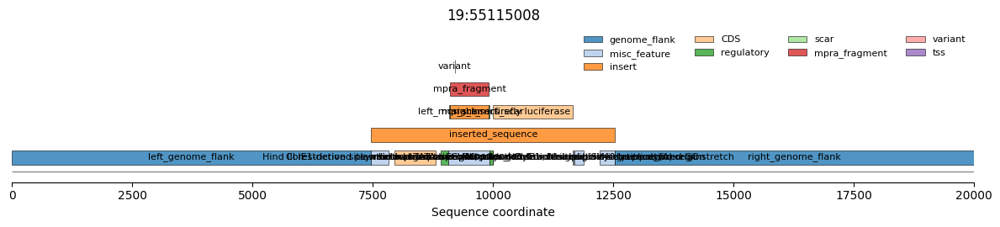

In [ ]:
results[0].input_ref.plot_annotations()

In [ ]:
with open('../data/corr_dict.json', 'w') as file:
    json.dump(corr_dict, file, indent=6)

In [ ]:
from collections import defaultdict
from collections.abc import Mapping
import math


def average_correlations_by_prefix(
    correlations: Mapping[str, float],
) -> dict[str, float]:
    """
    Group elements by prefix and average their finite correlation values.

    Prefix rule:
        element.split(".")[0].split("-")[0].split("rs")[0]
    """
    values_by_prefix: dict[str, list[float]] = defaultdict(list)

    for element, value in correlations.items():
        prefix = (
            str(element)
            .split(".", 1)[0]
            .split("-", 1)[0]
            .split("rs", 1)[0]
        )

        try:
            value = float(value)
        except (TypeError, ValueError) as exc:
            raise TypeError(
                f"Correlation for {element!r} must be numeric, got {value!r}."
            ) from exc

        if math.isfinite(value):
            values_by_prefix[prefix].append(value)

    return {
        prefix: (
            sum(values) / len(values)
            if values
            else float("nan")
        )
        for prefix, values in values_by_prefix.items()
    }
def mean(el2corr):
    processed = average_correlations_by_prefix(el2corr)
    return np.mean(list(processed.values()))

(<Figure size 2280x461 with 1 Axes>, <Axes: title={'center': 'Promoters'}>)

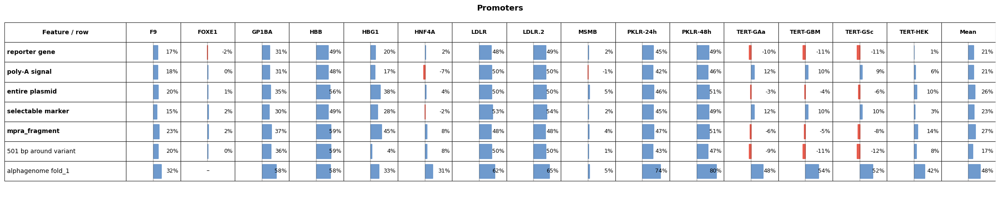

In [ ]:
plot_feature_correlation_table(correlations={k:v for k, v in corrs.items() if k in PROMOTER_ELEMENTS}, features_to_plot={'mpra_fragment', 'selectable marker', 'reporter gene', 'entire plasmid', 'poly-A signal'}, 
                                                    feature_rename={'beta-lactamase': 'selectable marker',
                                                                                                        'similar to beta-lactamase; confers resistance to ampicillin, carbenicillin, and related antibiotics': 'selectable marker',
                                                                                                        'firefly luciferase': 'reporter gene',
                                                                                                        'similar to firefly luciferase; synthetic luc2 version of the luciferase gene': 'reporter gene',
                                                                                                        'inserted_sequence': 'entire plasmid',
                                                                                                        'SV40 late poly(A) region': 'poly-A signal',
                                                                                                        'SV40 late poly (A) region': 'poly-A signal',
                                                                                                        'SV40 late polyA': 'poly-A signal',
                                                                                                        'SV40 polyadenylation signal; SV40 late poly(A) region': 'poly-A signal',
                                                                                                        'minimal TATA-box promoter with low basal activity': 'minimal promoter'
                                                                                                        },
                                                    title='Promoters',
                                                    additional_rows={
                                                        '501 bp around variant': {'BCL11A': 0.12625925117905426,
                                                                                    'F9': 0.20487283828633102,
                                                                                    'FOXE1': 0.004947508508490845,
                                                                                    'GP1BA': 0.3563257347219234,
                                                                                    'HBB': 0.5927781312088172,
                                                                                    'HBG1': 0.039394474429226146,
                                                                                    'HNF4A': 0.07520973994398414,
                                                                                    'IRF4': 0.39899298193043947,
                                                                                    'IRF6': 0.19624047444254955,
                                                                                    'LDLR': 0.49918983132733225,
                                                                                    'LDLR.2': 0.4999637636792505,
                                                                                    'MSMB': 0.013194963731142977,
                                                                                    'MYCrs11986220': 0.02559018642231635,
                                                                                    'MYCrs6983267': 0.08771609119554025,
                                                                                    'PKLR-24h': 0.42577426792354783,
                                                                                    'PKLR-48h': 0.46530672387660466,
                                                                                    'RET': 0.07925590358801235,
                                                                                    'SORT1': 0.053286344544520366,
                                                                                    'SORT1-flip': -0.00032808650562150777,
                                                                                    'SORT1.2': 0.04625973464266156,
                                                                                    'TCF7L2': -0.06477833505138726,
                                                                                    'TERT-GAa': -0.09467608032825657,
                                                                                    'TERT-GBM': -0.10742022719667728,
                                                                                    'TERT-GSc': -0.11869370779649803,
                                                                                    'TERT-HEK': 0.08235562016635282,
                                                                                    'UC88': 0.22359123479260634,
                                                                                    'ZFAND3': 0.10498439667946516,
                                                                                    'ZRSh-13': 0.10646926841551994,
                                                                                    'ZRSh-13h2': 0.15910545025108985},
                                                        'alphagenome fold_1': {'F9': 0.31728714205494446,
                                                                                'GP1BA': 0.5816504189651528,
                                                                                'HBB': 0.58134609703809,
                                                                                'HBG1': 0.32945875292047283,
                                                                                'HNF4A': 0.30658287735851053,
                                                                                'IRF4': 0.7276665259829245,
                                                                                'IRF6': 0.688767539365959,
                                                                                'LDLR': 0.6165281808481928,
                                                                                'LDLR.2': 0.6458270371565045,
                                                                                'MSMB': 0.05441078333694314,
                                                                                'MYCrs11986220': -0.01073324033826045,
                                                                                'MYCrs6983267': 0.3874566606541967,
                                                                                'PKLR-24h': 0.7390854516789516,
                                                                                'PKLR-48h': 0.8039249678391265,
                                                                                'SORT1': 0.7098379585780255,
                                                                                'SORT1-flip': 0.6898911964035332,
                                                                                'SORT1.2': 0.6784959353065811,
                                                                                'TERT-GAa': 0.4827466178814113,
                                                                                'TERT-GBM': 0.5378001158262097,
                                                                                'TERT-GSc': 0.5244270073283473,
                                                                                'TERT-HEK': 0.42458970739680746,
                                                                                'ZFAND3': 0.37890938467251206},
                                                    },
                                                    last_column_name="Mean",
                                                    last_column_score=lambda el2corr: mean(el2corr),
                                                    )

(<Figure size 1780x513 with 1 Axes>, <Axes: title={'center': 'Enhancers'}>)

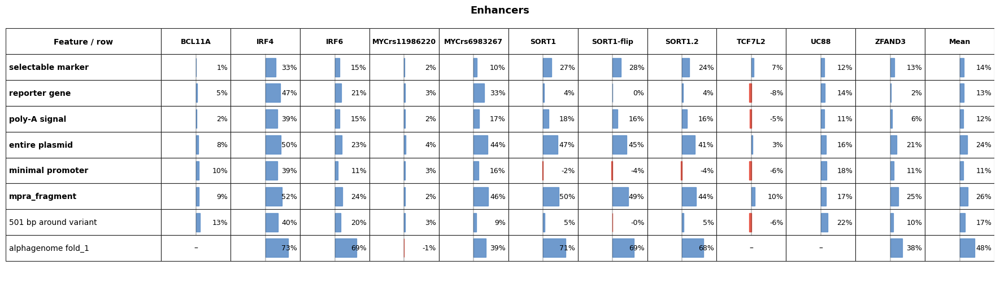

In [ ]:
plot_feature_correlation_table(correlations={k:v for k, v in corrs.items() if k in ENHANCER_ELEMENTS}, features_to_plot={'mpra_fragment', 'selectable marker', 'reporter gene', 'entire plasmid', 'poly-A signal','minimal promoter'}, 
                                                    feature_rename={'beta-lactamase': 'selectable marker',
                                                                    'similar to beta-lactamase; confers resistance to ampicillin, carbenicillin, and related antibiotics': 'selectable marker',
                                                                    'firefly luciferase': 'reporter gene',
                                                                    'similar to firefly luciferase; synthetic luc2 version of the luciferase gene': 'reporter gene',
                                                                    'inserted_sequence': 'entire plasmid',
                                                                    'SV40 late poly(A) region': 'poly-A signal',
                                                                    'SV40 late poly (A) region': 'poly-A signal',
                                                                    'SV40 late polyA': 'poly-A signal',
                                                                    'SV40 polyadenylation signal; SV40 late poly(A) region': 'poly-A signal',
                                                                    'minimal TATA-box promoter with low basal activity': 'minimal promoter'
                                                                    },
                                                    title='Enhancers',
                                                    additional_rows={
                                                        '501 bp around variant': {'BCL11A': 0.12625925117905426,
                                                                                    'F9': 0.20487283828633102,
                                                                                    'FOXE1': 0.004947508508490845,
                                                                                    'GP1BA': 0.3563257347219234,
                                                                                    'HBB': 0.5927781312088172,
                                                                                    'HBG1': 0.039394474429226146,
                                                                                    'HNF4A': 0.07520973994398414,
                                                                                    'IRF4': 0.39899298193043947,
                                                                                    'IRF6': 0.19624047444254955,
                                                                                    'LDLR': 0.49918983132733225,
                                                                                    'LDLR.2': 0.4999637636792505,
                                                                                    'MSMB': 0.013194963731142977,
                                                                                    'MYCrs11986220': 0.02559018642231635,
                                                                                    'MYCrs6983267': 0.08771609119554025,
                                                                                    'PKLR-24h': 0.42577426792354783,
                                                                                    'PKLR-48h': 0.46530672387660466,
                                                                                    'RET': 0.07925590358801235,
                                                                                    'SORT1': 0.053286344544520366,
                                                                                    'SORT1-flip': -0.00032808650562150777,
                                                                                    'SORT1.2': 0.04625973464266156,
                                                                                    'TCF7L2': -0.06477833505138726,
                                                                                    'TERT-GAa': -0.09467608032825657,
                                                                                    'TERT-GBM': -0.10742022719667728,
                                                                                    'TERT-GSc': -0.11869370779649803,
                                                                                    'TERT-HEK': 0.08235562016635282,
                                                                                    'UC88': 0.22359123479260634,
                                                                                    'ZFAND3': 0.10498439667946516,
                                                                                    'ZRSh-13': 0.10646926841551994,
                                                                                    'ZRSh-13h2': 0.15910545025108985},
                                                        'alphagenome fold_1': {'F9': 0.31728714205494446,
                                                                                'GP1BA': 0.5816504189651528,
                                                                                'HBB': 0.58134609703809,
                                                                                'HBG1': 0.32945875292047283,
                                                                                'HNF4A': 0.30658287735851053,
                                                                                'IRF4': 0.7276665259829245,
                                                                                'IRF6': 0.688767539365959,
                                                                                'LDLR': 0.6165281808481928,
                                                                                'LDLR.2': 0.6458270371565045,
                                                                                'MSMB': 0.05441078333694314,
                                                                                'MYCrs11986220': -0.01073324033826045,
                                                                                'MYCrs6983267': 0.3874566606541967,
                                                                                'PKLR-24h': 0.7390854516789516,
                                                                                'PKLR-48h': 0.8039249678391265,
                                                                                'SORT1': 0.7098379585780255,
                                                                                'SORT1-flip': 0.6898911964035332,
                                                                                'SORT1.2': 0.6784959353065811,
                                                                                'TERT-GAa': 0.4827466178814113,
                                                                                'TERT-GBM': 0.5378001158262097,
                                                                                'TERT-GSc': 0.5244270073283473,
                                                                                'TERT-HEK': 0.42458970739680746,
                                                                                'ZFAND3': 0.37890938467251206}
                                                    },
                                                    last_column_name="Mean",
                                                    last_column_score=lambda el2corr: mean(el2corr),
                                                    )

In [ ]:
compute_element_correlations(
    result = dataset.with_columns(scores = pl.Series(name='scores', values = scores)),
    pred_col='scores'
)

{'BCL11A': 0.12625925117905426,
 'F9': 0.20487283828633102,
 'FOXE1': 0.004947508508490845,
 'GP1BA': 0.3563257347219234,
 'HBB': 0.5927781312088172,
 'HBG1': 0.039394474429226146,
 'HNF4A': 0.07520973994398414,
 'IRF4': 0.39899298193043947,
 'IRF6': 0.19624047444254955,
 'LDLR': 0.49918983132733225,
 'LDLR.2': 0.4999637636792505,
 'MSMB': 0.013194963731142977,
 'MYCrs11986220': 0.02559018642231635,
 'MYCrs6983267': 0.08771609119554025,
 'PKLR-24h': 0.42577426792354783,
 'PKLR-48h': 0.46530672387660466,
 'RET': 0.07925590358801235,
 'SORT1': 0.053286344544520366,
 'SORT1-flip': -0.00032808650562150777,
 'SORT1.2': 0.04625973464266156,
 'TCF7L2': -0.06477833505138726,
 'TERT-GAa': -0.09467608032825657,
 'TERT-GBM': -0.10742022719667728,
 'TERT-GSc': -0.11869370779649803,
 'TERT-HEK': 0.08235562016635282,
 'UC88': 0.22359123479260634,
 'ZFAND3': 0.10498439667946516,
 'ZRSh-13': 0.10646926841551994,
 'ZRSh-13h2': 0.15910545025108985}

In [ ]:
dataset.with_columns(scores = pl.Series(name='scores', values = scores)).select('Value', 'scores').corr()

Value,scores
f64,f64
1.0,0.278785
0.278785,1.0


In [154]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_correlation_json(
    json_path,
    output_path=None,
    *,
    title=None,
    figsize=None,
):
    """Plot forward, reverse, and mean correlations for every element."""
    json_path = Path(json_path)

    with json_path.open("r", encoding="utf-8") as file:
        correlations = json.load(file)

    elements = list(correlations)
    strands = ("forward", "reverse", "mean")
    colors = ("#4C78A8", "#F58518", "#54A24B")

    x = np.arange(len(elements))
    bar_width = 0.25

    if figsize is None:
        figsize = (max(12, len(elements) * 0.7), 6)

    fig, ax = plt.subplots(figsize=figsize)

    for index, (strand, color) in enumerate(zip(strands, colors)):
        values = [
            np.nan
            if correlations[element].get(strand) is None
            else float(correlations[element][strand])
            for element in elements
        ]

        ax.bar(
            x + (index - 1) * bar_width,
            values,
            width=bar_width,
            label=strand.capitalize(),
            color=color,
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(elements, rotation=45, ha="right")
    ax.set_ylabel("Pearson correlation")
    ax.set_ylim(-0.25, 0.7)
    ax.set_title(title or json_path.stem.replace("_", " ").title())
    ax.legend()
    ax.grid(axis="y", alpha=0.2)

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches="tight")

    return fig, ax

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'New checkpoint, expression delta scorer'}, ylabel='Pearson correlation'>)

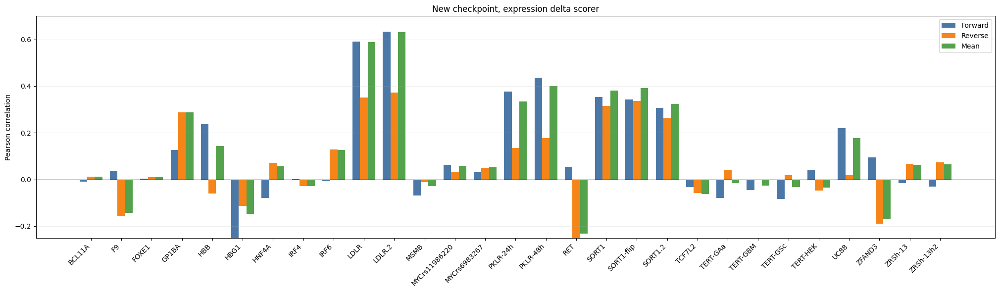

In [155]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/forward_reverse_variant_api/expression_correlations.json', title='New checkpoint, expression delta scorer')

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'New checkpoint, expression delta scorer'}, ylabel='Pearson correlation'>)

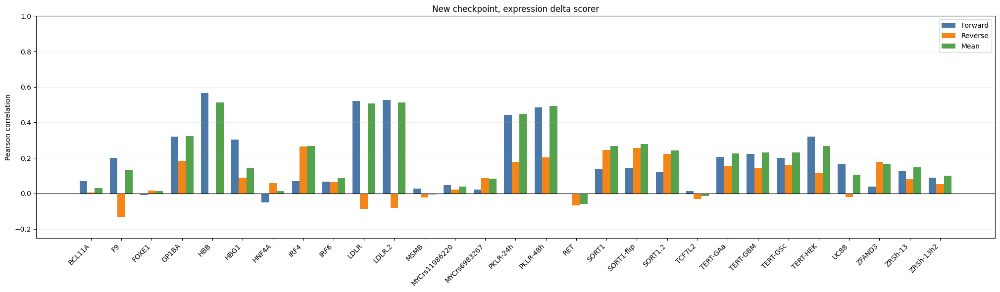

In [ ]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/expression_correlations.json', title='New checkpoint, expression delta scorer')

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'New checkpoint, ATAC-seq sum over mpra fragment'}, ylabel='Pearson correlation'>)

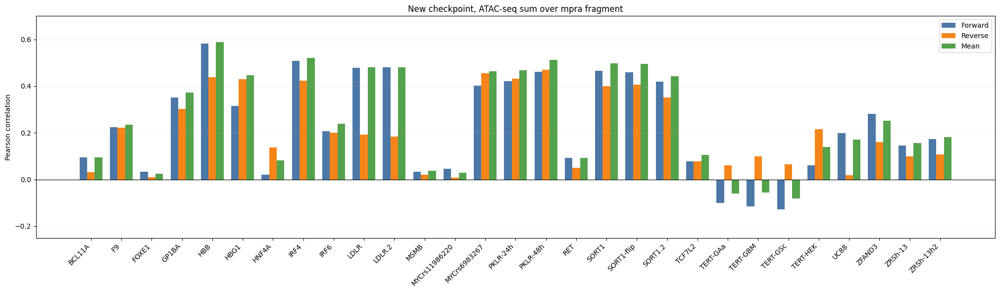

In [ ]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/track_feature_correlations.json', title='New checkpoint, ATAC-seq sum over mpra fragment')

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'Old checkpoint, ATAC-seq sum over mpra fragment'}, ylabel='Pearson correlation'>)

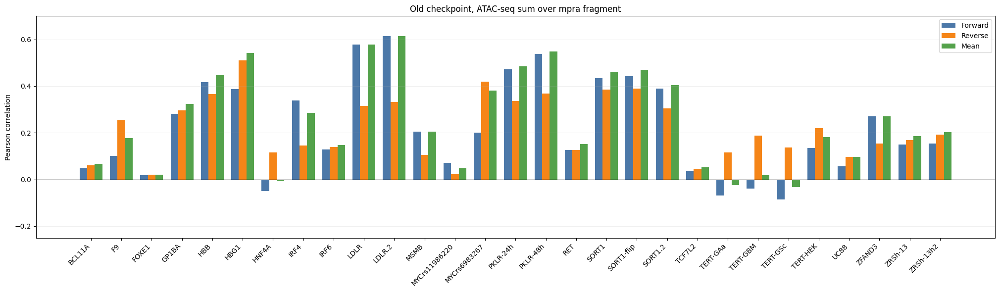

In [ ]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/forward_reverse_variant_api/track_feature_correlations.json', title='Old checkpoint, ATAC-seq sum over mpra fragment')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


def plot_true_vs_pred(
    df: pl.DataFrame,
    prediction_col: str,
    element: str,
    target_col: str = "Value",
):
    """Plot true values against predictions from one DataFrame column."""
    data = df.filter(pl.col.Element == element).select(target_col, prediction_col).drop_nulls()

    true = data[target_col].to_numpy()
    predicted = data[prediction_col].to_numpy()

    finite = np.isfinite(true) & np.isfinite(predicted)
    true = true[finite]
    predicted = predicted[finite]

    if len(true) == 0:
        raise ValueError("No finite true/predicted value pairs to plot.")

    fig, ax = plt.subplots(figsize=(6, 6))
    corr = np.round(np.corrcoef(true, predicted)[0, 1], decimals=2)
    ax.scatter(true, predicted, alpha=0.3, s=20)

    #lower = min(true.min(), predicted.min())
    #upper = max(true.max(), predicted.max())
    #ax.plot([lower, upper], [lower, upper], "--", color="gray")

    ax.set_xlabel(target_col)
    ax.set_ylabel(prediction_col)
    ax.set_title(f"True vs predicted: {prediction_col}, element: {element}, corr: {corr}")

    fig.tight_layout()
    return fig, ax

In [ ]:
new_checkpoint = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/dataset_with_predictions.tsv', separator='\t', infer_schema_length=10000)

In [ ]:
new_checkpoint

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,expr_forward,expr_reverse,expr_mean,track_feature_forward,track_feature_reverse,track_feature_mean
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494939:C>-""",-0.014587,-0.013672,-0.01413,9.200195,-4.173828,2.513184
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494939:C>A""",-0.009521,-0.009766,-0.009644,21.207031,-0.984375,10.111328
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494939:C>G""",-0.008118,0.009766,0.000824,11.739258,1.8046875,6.771973
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494939:C>T""",-0.023483,0.003906,-0.009789,8.0859375,3.951172,6.018555
"""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494940:C>A""",-0.002319,0.011719,0.0047,16.495117,6.324219,11.409668
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791601,"""G""","""T""",1676,12030,37310,0.1,0.00001,"""chr7:156791601:G>T""",-0.010742,-0.002686,-0.006714,-8.041016,-11.605469,-9.823242
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224,"""chr7:156791602:C>-""",0.000488,0.019775,0.010132,-1.853516,4.667969,1.407227
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""A""",25,107,309,-0.17,0.33374,"""chr7:156791602:C>A""",0.0,-0.004639,-0.002319,0.400391,-0.283203,0.058594


In [ ]:
old_checkpoint = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/forward_reverse_variant_api/dataset_with_predictions.tsv', separator='\t', infer_schema_length=10000)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'True vs predicted: score, element: HBG1, corr: -0.42'}, xlabel='Value', ylabel='score'>)

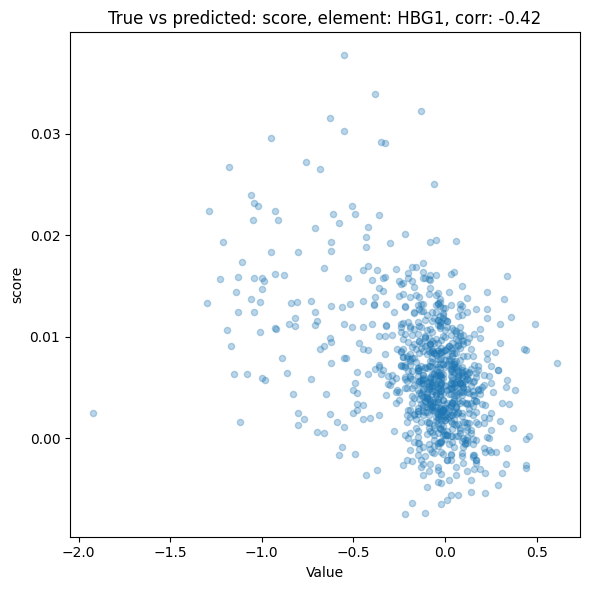

In [ ]:
plot_true_vs_pred(df=dataset_results, prediction_col='score', element='HBG1')

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'True vs predicted: track_feature_mean, element: SORT1, corr: 0.5'}, xlabel='Value', ylabel='track_feature_mean'>)

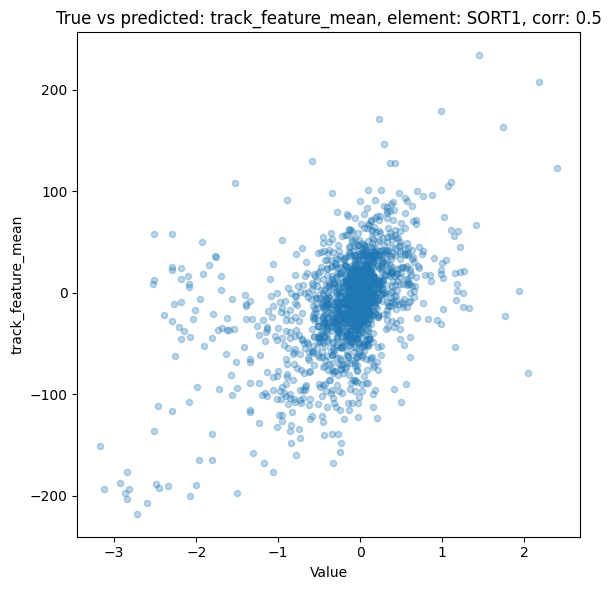

In [ ]:
plot_true_vs_pred(df=new_checkpoint, prediction_col='track_feature_mean', element='SORT1')

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'True vs predicted: expr_forward'}, xlabel='Value', ylabel='expr_forward'>)

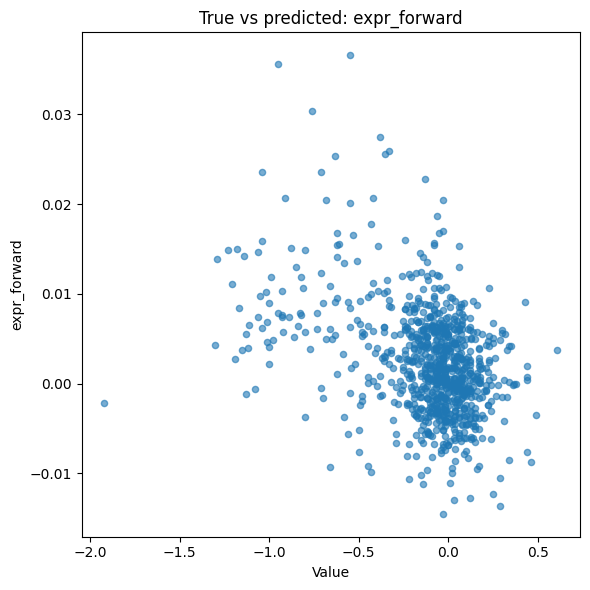

In [ ]:
plot_true_vs_pred(df=old_checkpoint, prediction_col='expr_forward', element='HBG1')

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from matplotlib.figure import Figure
from matplotlib.lines import Line2D


def plot_cagi5_variant_effects(
    df: pl.DataFrame,
    *,
    element_col: str,
    position_col: str,
    ref_col: str,
    alt_col: str,
    target_col: str,
    prediction_col: str,
    element_name: str,
    figsize: tuple[float, float] = (16, 8),
) -> tuple[Figure, np.ndarray]:
    """
    Plot measured and predicted variant effects for one CAGI5 element.

    Colors encode the alternative nucleotide.
    Marker shapes encode the reference nucleotide.
    Positions are shown relative to the first assayed position.
    """
    required_columns = [
        element_col,
        position_col,
        ref_col,
        alt_col,
        target_col,
        prediction_col,
    ]

    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise ValueError(f"Missing dataframe columns: {missing}")

    element_df = (
        df.filter(pl.col(element_col) == element_name)
        .select(required_columns)
        .sort([position_col, ref_col, alt_col])
    )

    if element_df.is_empty():
        raise ValueError(
            f"No rows found for {element_col}={element_name!r}"
        )

    positions = (
        element_df.get_column(position_col)
        .cast(pl.Float64)
        .to_numpy()
    )

    if not np.isfinite(positions).all():
        raise ValueError(f"{position_col!r} contains missing or non-finite values")

    # Preserve distances between variants without displaying genomic coordinates.
    x = positions - positions.min()

    references = (
        element_df.get_column(ref_col)
        .cast(pl.Utf8)
        .str.to_uppercase()
        .to_numpy()
    )
    alternatives = (
        element_df.get_column(alt_col)
        .cast(pl.Utf8)
        .str.to_uppercase()
        .to_numpy()
    )

    alt_colors = {
        "A": "#159447",  # green
        "C": "#2468A2",  # blue
        "G": "#F2A51A",  # orange
        "T": "#DC2638",  # red
        "-": "#6B7280",  # deletion
    }

    ref_markers = {
        "A": "s",  # square
        "C": "o",  # circle
        "G": "^",  # triangle
        "T": "D",  # diamond
    }

    invalid_ref = sorted(set(references) - set(ref_markers))
    invalid_alt = sorted(set(alternatives) - set(alt_colors))

    if invalid_ref:
        raise ValueError(f"Unsupported reference alleles: {invalid_ref}")
    if invalid_alt:
        raise ValueError(f"Unsupported alternative alleles: {invalid_alt}")

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
    )

    def draw_panel(ax, value_col: str, title: str) -> None:
        values = (
            element_df.get_column(value_col)
            .cast(pl.Float64)
            .to_numpy()
        )
        valid = np.isfinite(values)

        if not valid.any():
            raise ValueError(
                f"{value_col!r} has no finite values for {element_name!r}"
            )

        point_colors = [alt_colors[base] for base in alternatives[valid]]

        ax.vlines(
            x[valid],
            ymin=0,
            ymax=values[valid],
            colors=point_colors,
            linewidth=0.8,
            alpha=0.75,
            zorder=1,
        )

        for reference, marker in ref_markers.items():
            mask = valid & (references == reference)
            if not mask.any():
                continue

            ax.scatter(
                x[mask],
                values[mask],
                c=[alt_colors[base] for base in alternatives[mask]],
                marker=marker,
                s=22,
                linewidths=0,
                zorder=2,
            )

        ax.axhline(0, color="#444444", linewidth=0.8, zorder=0)
        ax.set_title(title, loc="left", fontsize=12, fontweight="bold")
        ax.set_ylabel("Variant effect")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        lower = min(0.0, float(values[valid].min()))
        upper = max(0.0, float(values[valid].max()))

        if lower == upper:
            ax.set_ylim(-0.5, 0.5)
        else:
            padding = 0.08 * (upper - lower)
            ax.set_ylim(lower - padding, upper + padding)

    draw_panel(axes[0], target_col, f"Measured — {target_col}")
    draw_panel(axes[1], prediction_col, f"Model prediction — {prediction_col}")

    axes[0].tick_params(axis="x", labelbottom=False)
    axes[1].set_xlabel("Position relative to first assayed base (bp)")
    axes[1].ticklabel_format(axis="x", style="plain", useOffset=False)

    alt_handles = [
        Line2D(
            [],
            [],
            linestyle="none",
            marker="s",
            markersize=8,
            markerfacecolor=color,
            markeredgecolor=color,
            label=base,
        )
        for base, color in alt_colors.items()
    ]

    ref_handles = [
        Line2D(
            [],
            [],
            linestyle="none",
            marker=marker,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="#555555",
            label=base,
        )
        for base, marker in ref_markers.items()
    ]

    fig.legend(
        handles=alt_handles,
        title="Alternative",
        ncol=4,
        loc="lower center",
        bbox_to_anchor=(0.40, 0.01),
        frameon=False,
    )
    fig.legend(
        handles=ref_handles,
        title="Reference",
        ncol=4,
        loc="lower center",
        bbox_to_anchor=(0.70, 0.01),
        frameon=False,
    )

    fig.suptitle(str(element_name), fontsize=16, fontweight="bold")
    fig.subplots_adjust(
        left=0.09,
        right=0.98,
        top=0.90,
        bottom=0.17,
        hspace=0.10,
    )
    fig.align_ylabels(axes)

    return fig, axes

In [10]:
results = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/dataset_with_predictions.tsv', separator='\t', infer_schema_length=10000)

In [11]:
results

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,expr_forward,expr_reverse,expr_mean,track_feature_forward,track_feature_reverse,track_feature_mean
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494939:C>-""",-0.014587,-0.013672,-0.01413,9.200195,-4.173828,2.513184
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494939:C>A""",-0.009521,-0.009766,-0.009644,21.207031,-0.984375,10.111328
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494939:C>G""",-0.008118,0.009766,0.000824,11.739258,1.8046875,6.771973
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494939:C>T""",-0.023483,0.003906,-0.009789,8.0859375,3.951172,6.018555
"""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494940:C>A""",-0.002319,0.011719,0.0047,16.495117,6.324219,11.409668
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791601,"""G""","""T""",1676,12030,37310,0.1,0.00001,"""chr7:156791601:G>T""",-0.010742,-0.002686,-0.006714,-8.041016,-11.605469,-9.823242
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224,"""chr7:156791602:C>-""",0.000488,0.019775,0.010132,-1.853516,4.667969,1.407227
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""A""",25,107,309,-0.17,0.33374,"""chr7:156791602:C>A""",0.0,-0.004639,-0.002319,0.400391,-0.283203,0.058594


In [12]:
element_list = results['Element'].unique().to_list()

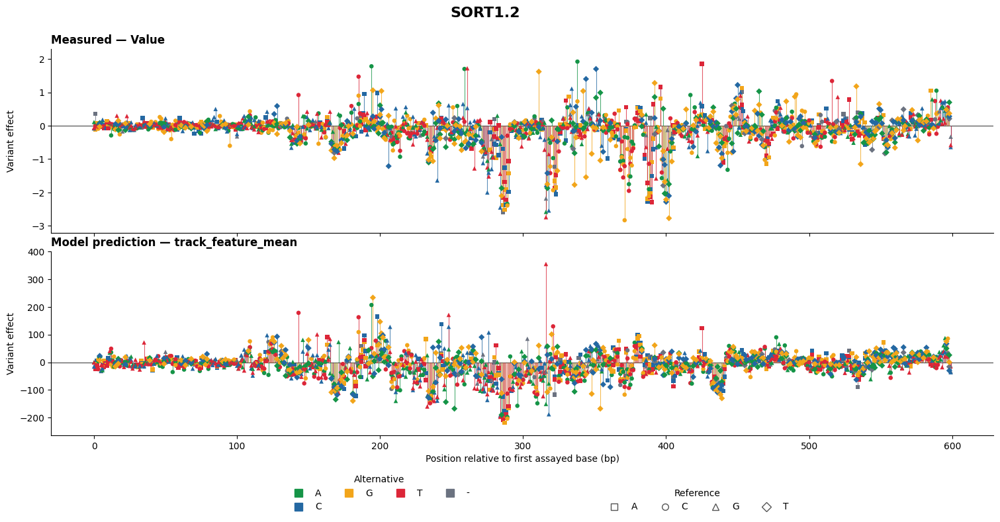

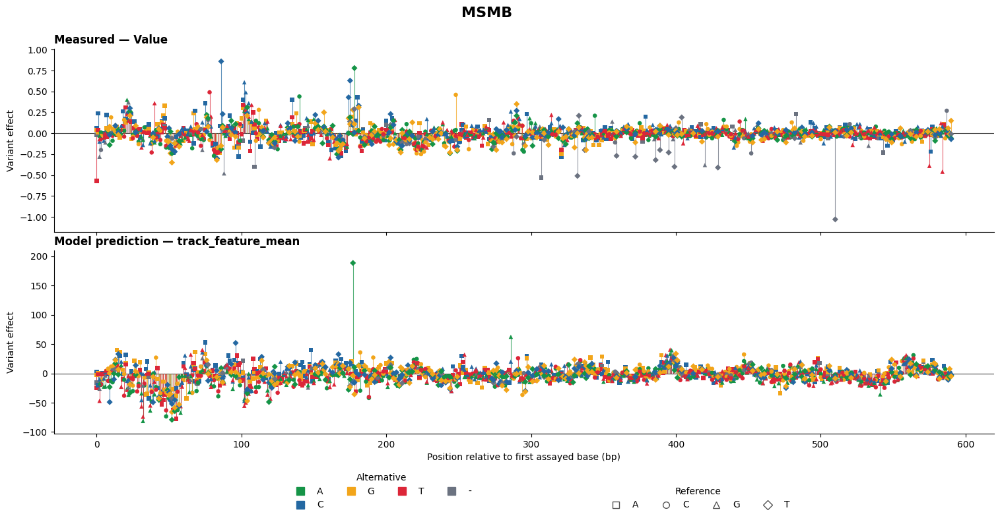

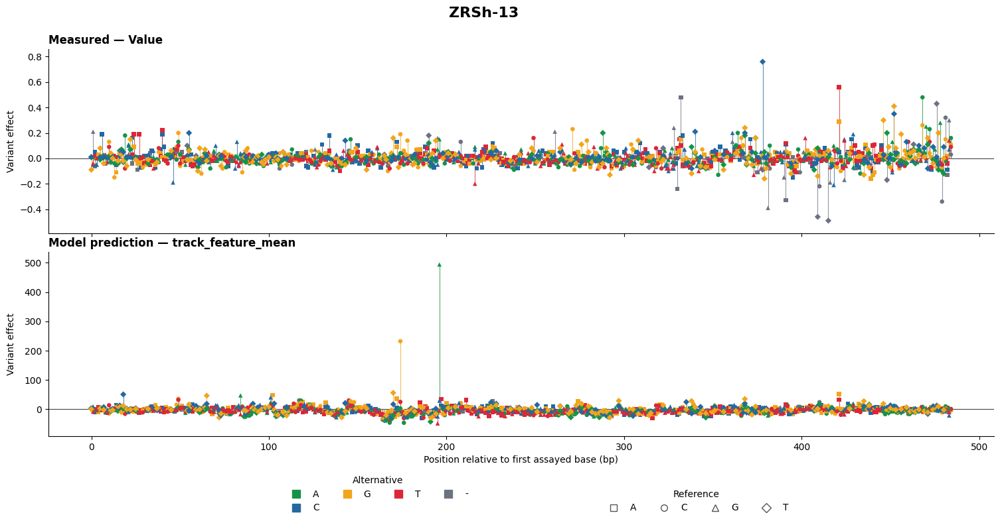

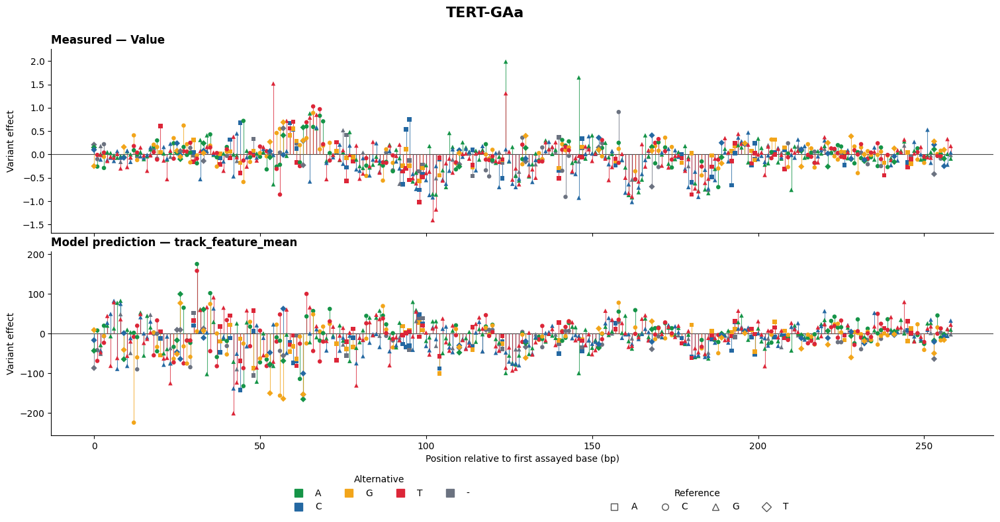

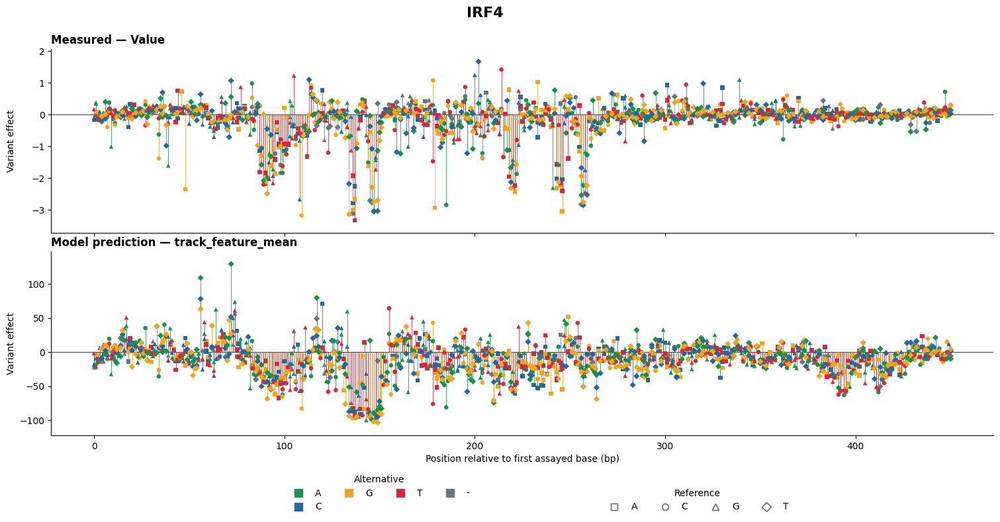

...

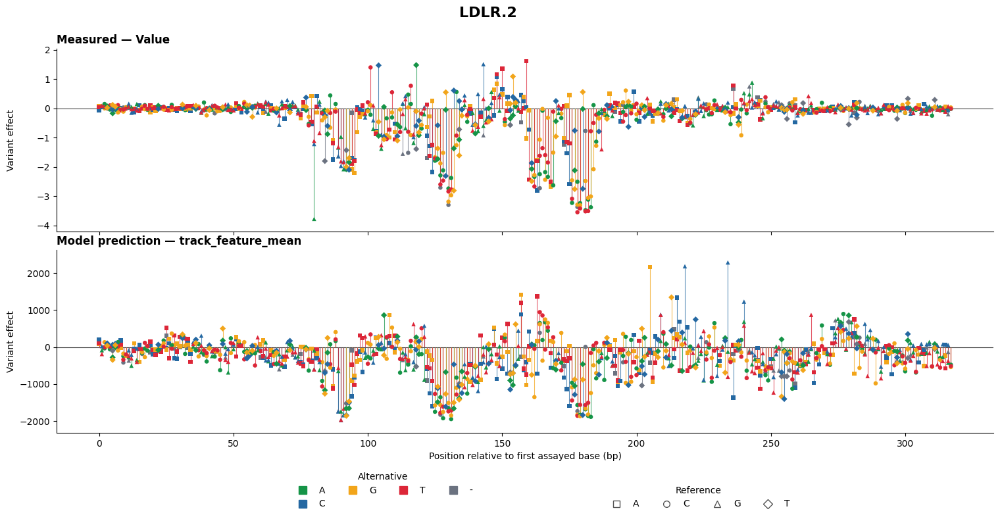

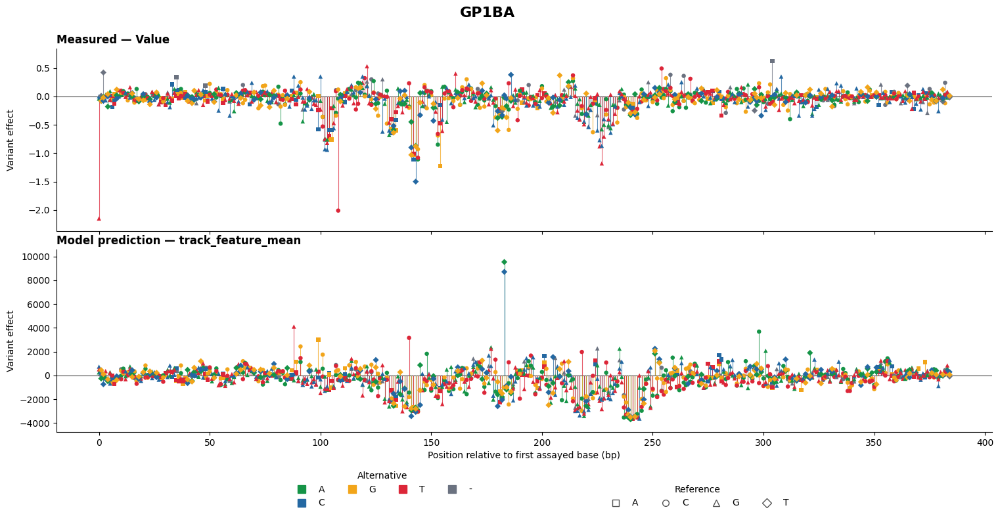

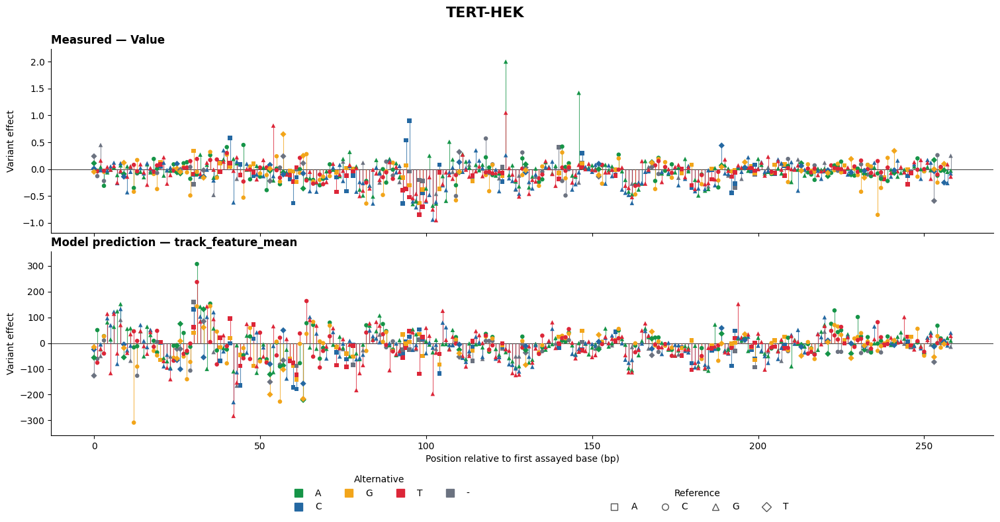

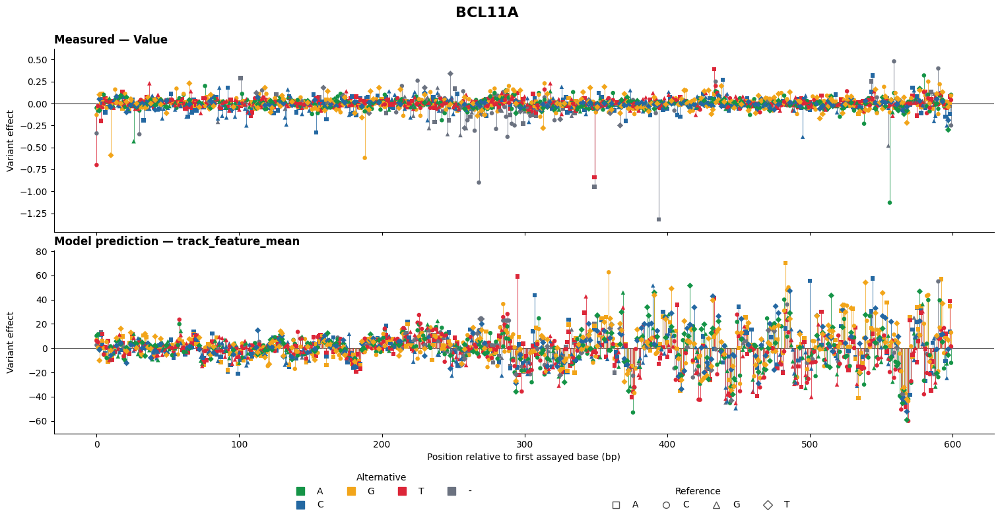

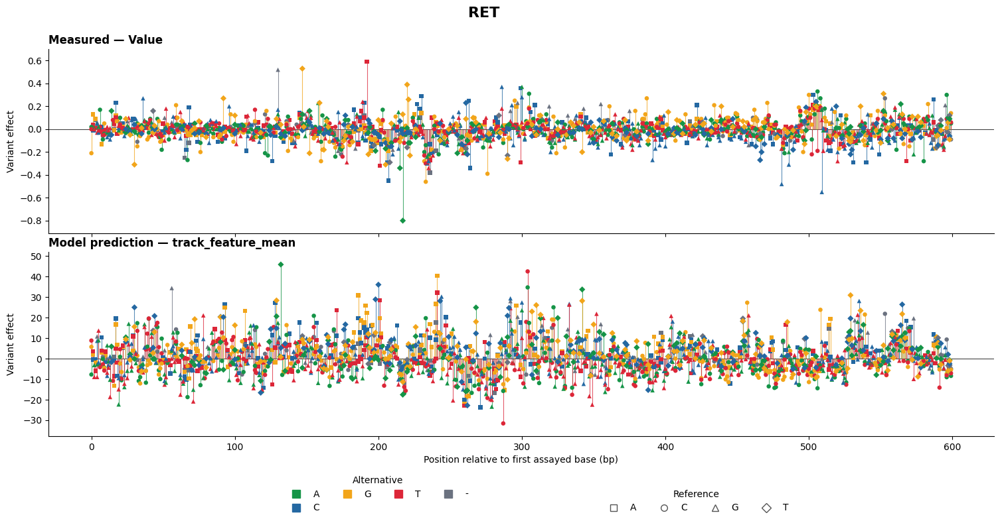

In [14]:
for element in element_list:
    plot_cagi5_variant_effects(df = results,
                                element_col='Element',
                                position_col='Position',
                                ref_col='Ref',
                                alt_col='Alt',
                                target_col='Value',
                                prediction_col='track_feature_mean',
                                element_name=element)
    plt.show()
    plt.close()